# Diagonal moment–SoS recovery of a 2-D Gaussian mixture (§4.4)

Self-contained notebook for §4.4 of the paper. It recovers a planar **3-component** Gaussian mixture
(known covariance $\sigma^2 I$) from an i.i.d. sample: the low-order moments of the mixing measure
$\mu^\star=\sum_{k=1}^3 a_k\delta_{t_k}$ are estimated by characteristic-function (CF) deconvolution over
a frequency band $\|\xi\|\le1/\tau$, then a small moment SDP is solved and flat-extracted. It applies the
**Christoffel–Darboux strengthening** of §3.4 (iterative **H1** and marginal **H2**), prints recovery
diagnostics and every solver status, and displays the figures inline while saving them to `../figs/`.

**What is solved.** The polynomial moment–SoS BLASSO with a Mercer-weighted least-squares fit of the raw
moments $m_\alpha=\int t^\alpha\,\mathrm d\mu$. It shares the feasible cone of the diagonal kernel
relaxation (Remark `rem:diagonal`) but not its data functional. It does not solve the sketched program of
Section 4; it isolates the truncation mechanism of Remark `rem:smoothing-helps` in the moment coordinates.

**Two bands.** The code calls them `smooth` and `broad`.
* Band $1/\tau=1$ (`smooth`, panel (a)): $|\xi^\top t|\le1$ at the atoms, the degree-4 polynomial model
  of $e^{i\xi^\top t}$ is accurate (moment error $10^{-2}$ on exact data) and the three atoms are recovered.
* Band $1/\tau=6$ (`broad`, panel (b)): $|\xi^\top t|$ reaches $\approx6$ at the atoms, the degree-4 model
  is wrong on the band (moment error $0.4$, with exact data as well) and the relaxation flat-extracts a
  wrong four-atom support. The failure is this truncation bias, not noise amplification: on the band
  $1/\widehat{G_\Sigma}\le5$, and the noise part of the moment error is smaller than at band 1 (Section 11).

The saved PDFs carry no titles: the paper labels the panels by the band, and the legend of panel (c)
names the band of each spectrum.

**Christoffel strengthening (§3.4).** After the diagonal solve we sharpen the rank-3 certificate on the
positive block, two ways:
* **H1 (iterative).** Add $L_y(\widetilde\Lambda_D^{y^\star_+})\le(1-\varepsilon)
  L_{y^\star_+}(\widetilde\Lambda_D^{y^\star_+})$ with the full kernel Christoffel function
  $\widetilde\Lambda_D^{y^\star_+}=v_D^\top(M_D(y^\star_+)+\rho_C I)^{-1}v_D$, and re-solve.
* **H2 (marginal / local-solution).** Per coordinate, a univariate marginal Christoffel sublevel constraint
  $\widetilde\Lambda_{d_m}^{y^\star_{+,[i]}}(x_i)\le\gamma_i$ with the threshold set from the recovered
  atoms (the local solutions), normalised to $O(1)$, with a solver time cap.

**Outputs.** `fig_blasso_2dgmm_{a,b,c}.pdf` (recovery and conditioning; panel (c) overlays H1 and H2) and
`fig_blasso_2dgmm_certif.pdf` (3-D dual certificates). Section 11 prints the numbers quoted in §4.4 and
Section 12 lists every solver status.

In [1]:
# Dependencies (skip if already installed). The stored outputs were produced with the versions
# printed below (also listed in requirements.txt).
import sys, subprocess
try:
    import numpy, scipy, matplotlib, cvxpy  # noqa
except Exception:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",
                           "numpy>=1.24","scipy>=1.10","matplotlib>=3.7","cvxpy>=1.4"])
import numpy, matplotlib, cvxpy, clarabel, scs
print("python", sys.version.split()[0], "| numpy", numpy.__version__, "| matplotlib", matplotlib.__version__,
      "| cvxpy", cvxpy.__version__, "| clarabel", clarabel.__version__, "| scs", scs.__version__)

python 3.13.3 | numpy 2.3.3 | matplotlib 3.10.6 | cvxpy 1.9.1 | clarabel 0.11.1 | scs 3.2.11


## 1. Configuration

Three atoms (a triangle in $[-1.2,1.2]^2$, weights $0.5,0.3,0.2$), $\sigma=0.3$, sample
$n=2\times10^4$. The diagonal SDP uses relaxation order `D_ORDER=6` ($28\times28$ moment
matrices); we fit moments up to degree `D_DATA=4` (three atoms are over-determined by
degree $\le4$), weighted by the Gaussian–Mercer metric
$\lambda_\alpha=1/(\alpha_1!\,\alpha_2!\,(2\sigma^2)^{|\alpha|})$. Christoffel parameters:
H1 uses gap `EPS_CDK` and regularisation `BETA_CDK`; H2 uses marginal order `D_MARG`,
regularisation `BETA_MARG`, and threshold slack `H2_MARGIN`.

In [2]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: registers 3d projection

SIGMA   = 0.3                      # Gaussian width for CF and data weight
ATOMS   = np.array([[-0.7,-0.7],[0.7,0.7],[0.7,-0.7]])   # 3-component triangle
WEIGHTS = np.array([0.5,0.3,0.2])
BOX     = 1.2                      # parameter domain X = [-BOX,BOX]^2 (contains the atoms)
N       = 20_000
D_ORDER = 6                        # relaxation order (moment matrix uses degree <= D)
D_DATA  = 4                        # fit moments up to this degree (3 atoms need <= ~3-4)
BAND_SMOOTH = 1.0                  # CF band radius 1/tau = 1 (panel (a)): degree-4 CF model accurate
BAND_BROAD  = 6.0                  # CF band radius 1/tau = 6 (panel (b)): degree-4 CF model biased (truncation)
BETA    = 1e-3
RANK_TOL= 3e-2                     # 4th sing. value ~0.015 sits below this -> rank 3
SEED    = 0

# --- Christoffel--Darboux strengthening (§3.4) ---
EPS_CDK  = 0.20                    # H1 penalised-threshold gap: gamma = (1-eps) * L_{y*}(Lambda)
BETA_CDK = 1e-3                    # H1 Christoffel regularisation rho_C (full matrix)
N_CDK    = 4                       # H1 re-solves (with support-preserving safeguard)
D_MARG   = 3                       # H2 marginal (univariate) Christoffel order (< D_ORDER)
BETA_MARG= 1e-2                    # H2 marginal regularisation rho_C (tames the marginal inverse)
H2_MARGIN= 0.5                     # H2 threshold slack: gamma_i = 1.5 x max at the recovered atoms
SOLVE_TLIM = 120.0                 # solver time cap (s) -- guards against ill-conditioned solves

def lam(alpha):                    # Gaussian-Mercer data weight
    a,b = alpha
    return 1.0/(math.factorial(a)*math.factorial(b)*(2*SIGMA**2)**(a+b))

print(f"3 atoms; D={D_ORDER} -> moment matrix {math.comb(D_ORDER+2,2)}x{math.comb(D_ORDER+2,2)}; "
      f"fit moments up to degree {D_DATA}")

3 atoms; D=6 -> moment matrix 28x28; fit moments up to degree 4


## 2. Monomials, the sample, and the true mixing moments

`true_moments` gives the exact $\int t^\alpha d\mu^\star$ (for the sanity checks).

In [3]:
def monomials_upto(deg):
    monos=[(a,t-a) for t in range(deg+1) for a in range(t+1)]
    return monos, {e:i for i,e in enumerate(monos)}

MAXDEG = 2*D_ORDER
MONOS, IDX = monomials_upto(MAXDEG)

def draw_sample(rng):
    comp = rng.choice(len(WEIGHTS), size=N, p=WEIGHTS)
    return ATOMS[comp] + SIGMA*rng.standard_normal((N,2))

def true_moments():
    m = np.zeros(len(MONOS))
    for e in MONOS:
        m[IDX[e]] = np.sum(WEIGHTS*ATOMS[:,0]**e[0]*ATOMS[:,1]**e[1])
    return m

rng = np.random.default_rng(SEED)
X = draw_sample(rng)
print("sample:", X.shape)

sample: (20000, 2)


## 3. Moment estimation

**Raw-moment deconvolution (sanity check only, not used for the figures).** With $X=T+\sigma Z$,
$Z\sim\mathcal N(0,I)$,
$$\mathbb E[X^\alpha]=\sum_{\beta\le\alpha}\binom{\alpha}{\beta}\,\mathbb E[T^\beta]\,
   \sigma^{|\alpha-\beta|}\,\mu_Z(\alpha-\beta),$$
with $\mu_Z(k)=(k-1)!!$ for even $k$, else $0$. This is lower-triangular with unit diagonal in
$\mathbb E[T^\beta]$, so it can be inverted on the empirical raw moments
$\widehat{\mathbb E}[X^\alpha]=\frac1n\sum_j X_j^\alpha$. Exact in expectation.

**Band-limited CF deconvolution (used for both bands).** The empirical characteristic function
$\widehat\varphi_n(\xi)=\frac1n\sum_j e^{i\xi^\top X_j}$ estimates $\widehat{G_\Sigma}(\xi)\,\widehat{\mu^\star}(\xi)$.
On the 81 lattice frequencies of the disk $\|\xi\|\le1/\tau$ we form
$\widehat\nu(\xi)=\widehat\varphi_n(\xi)/\widehat{G_\Sigma}(\xi)$ and least-squares fit
$\widehat\nu(\xi)=\sum_{|\alpha|\le4}\tfrac{i^{|\alpha|}}{\alpha!}m_\alpha\,\xi^\alpha$. The fit is only as good
as the degree-4 model of $e^{i\xi^\top t}$ on the band: accurate at $1/\tau=1$, biased at $1/\tau=6$ (a
truncation bias, present with exact data). The division by $\widehat{G_\Sigma}$ amplifies the sampling noise
by at most $e^{\sigma^2/(2\tau^2)}$, about $5$ at $1/\tau=6$; Section 11 prints both parts of the error.

In [4]:
def _muZ(k):  # moment of standard normal
    return 0.0 if k%2 else float(math.prod(range(1,k,2))) if k>0 else 1.0

def raw_deconv_moments(X):     # reference only: not called by run(); cell 9 checks the same system
    raw = np.array([np.mean(X[:,0]**e[0]*X[:,1]**e[1]) for e in MONOS])  # E[X^alpha]
    n = len(MONOS); L = np.zeros((n,n))                                  # raw = L @ mixing
    for ia,a in enumerate(MONOS):
        for ib,b in enumerate(MONOS):
            if b[0]<=a[0] and b[1]<=a[1]:
                L[ia,ib]=(math.comb(a[0],b[0])*math.comb(a[1],b[1])
                          *SIGMA**((a[0]-b[0])+(a[1]-b[1]))*_muZ(a[0]-b[0])*_muZ(a[1]-b[1]))
    return np.linalg.solve(L, raw)

def cf_band_moments(X, band, ngrid=11):
    g = np.linspace(-band, band, ngrid)
    G1,G2 = np.meshgrid(g,g); XI = np.column_stack([G1.ravel(),G2.ravel()])
    XI = XI[np.sum(XI**2,axis=1) <= band**2 + 1e-9]                      # disk band
    phihat = np.exp(1j*(X@XI.T)).mean(axis=0)
    nuhat  = phihat/np.exp(-0.5*SIGMA**2*np.sum(XI**2,axis=1))           # deconvolve
    cols=[e for e in MONOS if e[0]+e[1] <= D_DATA]
    A = np.array([[(1j**(e[0]+e[1]))/(math.factorial(e[0])*math.factorial(e[1]))
                   *xi[0]**e[0]*xi[1]**e[1] for e in cols] for xi in XI])
    coef,*_ = np.linalg.lstsq(np.vstack([A.real,A.imag]),
                              np.concatenate([nuhat.real,nuhat.imag]), rcond=None)
    m = np.zeros(len(MONOS))
    for c,e in zip(coef, cols): m[IDX[e]] = c.real
    return m

**Sanity check** (in expectation, i.e. with the exact CF / exact raw moments):
both estimators must return the true mixing moments.

In [5]:
mt = true_moments()
# exact raw moments E[X^alpha] from the model -> raw deconv must invert to mt
rawL = np.zeros((len(MONOS),len(MONOS)))
for ia,a in enumerate(MONOS):
    for ib,b in enumerate(MONOS):
        if b[0]<=a[0] and b[1]<=a[1]:
            rawL[ia,ib]=(math.comb(a[0],b[0])*math.comb(a[1],b[1])
                         *SIGMA**((a[0]-b[0])+(a[1]-b[1]))*_muZ(a[0]-b[0])*_muZ(a[1]-b[1]))
exact_raw = rawL@mt
m_from_raw = np.linalg.solve(rawL, exact_raw)
print("raw deconv (exact): max err =", np.max(np.abs(m_from_raw-mt)))

# exact CF -> band deconv must match mt up to truncation/LS conditioning
class _Exact:                                  # object with .__matmul__ producing exact CF
    pass
g=np.linspace(-BAND_SMOOTH,BAND_SMOOTH,11); G1,G2=np.meshgrid(g,g); XI=np.column_stack([G1.ravel(),G2.ravel()])
XI=XI[np.sum(XI**2,axis=1)<=BAND_SMOOTH**2+1e-9]
mu_hat = (WEIGHTS[None,:]*np.exp(1j*(XI@ATOMS.T))).sum(axis=1)         # exact mu^star_hat
cols=[e for e in MONOS if e[0]+e[1]<=D_DATA]
A=np.array([[(1j**(e[0]+e[1]))/(math.factorial(e[0])*math.factorial(e[1]))
             *xi[0]**e[0]*xi[1]**e[1] for e in cols] for xi in XI])
coef,*_=np.linalg.lstsq(np.vstack([A.real,A.imag]),
                        np.concatenate([mu_hat.real,mu_hat.imag]),rcond=None)
m_from_cf=np.zeros(len(MONOS))
for c,e in zip(coef,cols): m_from_cf[IDX[e]]=c.real
print("CF band deconv (exact): max err on deg<=%d = %.2e"
      % (D_DATA, np.max([abs(m_from_cf[IDX[e]]-mt[IDX[e]]) for e in cols])))

raw deconv (exact): max err = 4.342012860369948e-15
CF band deconv (exact): max err on deg<=4 = 1.05e-02


## 4. The diagonal moment SDP

Variables: the moment vectors $y_+,y_-$ of the nonnegative parts $\mu_\pm$
($\mu=\mu_+-\mu_-$). We minimise the weighted moment-fit plus the TV (mass) penalty,
$$\min_{y_\pm}\;\tfrac12\!\!\sum_{|\alpha|\le d}\!\lambda_\alpha\big((y_+-y_-)_\alpha-\widehat m_\alpha\big)^2
   \;+\;\beta\,(y_{+,0}+y_{-,0}) \quad\text{s.t.}\quad M_D(y_\pm)\succeq0,\;\;M_{D-1}(g_i y_\pm)\succeq0,$$
with the box constraints $g_i=\mathrm{BOX}^2-x_i^2\ge0$. The constant is the monomial
$x^0$, so the total-variation/mass objective is simply $y_0$; no kernel augmentation is
needed in this (monomial-equivalent) diagonal computation.

In [6]:
def selector_moment(basis, index_full):
    nb=len(basis); T=np.zeros((nb*nb,len(index_full)))
    for a,ea in enumerate(basis):
        for b,eb in enumerate(basis):
            T[a*nb+b, index_full[(ea[0]+eb[0],ea[1]+eb[1])]]=1.0
    return T

def selector_localizing(basis, index_full, g_terms):
    nb=len(basis); T=np.zeros((nb*nb,len(index_full)))
    for a,ea in enumerate(basis):
        for b,eb in enumerate(basis):
            for coeff,sh in g_terms:
                T[a*nb+b, index_full[(ea[0]+eb[0]+sh[0],ea[1]+eb[1]+sh[1])]]+=coeff
    return T

SOLVE_LOG = []                               # one entry per cvxpy solve: (tag, solver, status, note)

def solve_moment_sdp(mhat, cdk=None, marg=None, tag=""):
    import cvxpy as cp
    basisD,_=monomials_upto(D_ORDER); basisDm1,_=monomials_upto(D_ORDER-1)
    Tm=selector_moment(basisD,IDX); b2=BOX**2
    Tl1=selector_localizing(basisDm1,IDX,[(b2,(0,0)),(-1,(2,0))])
    Tl2=selector_localizing(basisDm1,IDX,[(b2,(0,0)),(-1,(0,2))])
    fitcols=[IDX[e] for e in MONOS if e[0]+e[1]<=D_DATA]
    w=np.array([lam(MONOS[k]) for k in fitcols]); target=mhat[fitcols]
    yp=cp.Variable(len(MONOS)); ym=cp.Variable(len(MONOS)); diff=yp-ym
    nbD,nbL=len(basisD),len(basisDm1)
    Mp=cp.reshape(Tm@yp,(nbD,nbD),order="C"); Mm=cp.reshape(Tm@ym,(nbD,nbD),order="C")
    cons=[Mp>>0, Mm>>0,
          cp.reshape(Tl1@yp,(nbL,nbL),order="C")>>0, cp.reshape(Tl2@yp,(nbL,nbL),order="C")>>0,
          cp.reshape(Tl1@ym,(nbL,nbL),order="C")>>0, cp.reshape(Tl2@ym,(nbL,nbL),order="C")>>0]
    if cdk is not None:                       # H1: <Wcdk, M_D(y_+)> <= gamma  (rank-surrogate cap)
        Wcdk, gam = cdk
        cons.append(cp.sum(cp.multiply(Wcdk, Mp)) <= gam)
    if marg is not None:                      # H2: M_{D-d_m}((1 - Lambda_i(x_i)/gamma_i) y_+) >= 0
        for g_terms, lo in marg:
            basisLo,_=monomials_upto(lo); nlo=len(basisLo)
            Tlo=selector_localizing(basisLo, IDX, g_terms)
            cons.append(cp.reshape(Tlo@yp,(nlo,nlo),order="C")>>0)
    fit=0.5*cp.sum(cp.multiply(w, cp.square(diff[fitcols]-target)))
    obj=fit + BETA*(yp[IDX[(0,0)]]+ym[IDX[(0,0)]])
    prob=cp.Problem(cp.Minimize(obj),cons)
    try:
        prob.solve(solver=cp.CLARABEL, time_limit=SOLVE_TLIM)
        SOLVE_LOG.append((tag, "CLARABEL", prob.status, ""))
    except Exception as e:
        print("  CLARABEL failed:",e)
        SOLVE_LOG.append((tag, "CLARABEL", "failed", (str(e).split(". ")[0] or type(e).__name__)[:80]))
        try:
            prob.solve(solver=cp.SCS, max_iters=20000)
            SOLVE_LOG.append((tag, "SCS", prob.status, "fallback"))
        except Exception as e2:
            print("  SCS failed:",e2)
            SOLVE_LOG.append((tag, "SCS", "failed", (str(e2).split(". ")[0] or type(e2).__name__)[:80]))
    print(f"  solve [{tag}]: {SOLVE_LOG[-1][1]} status={SOLVE_LOG[-1][2]}")
    Adual=None
    try: Adual=cons[0].dual_value
    except Exception as e: print("  dual of M_D(y_+) >= 0 unavailable:", e)
    return yp.value, ym.value, basisD, fitcols, w, Adual

## 5. Curto–Fialkow extraction (verified routine)

In [7]:
def moment_matrix(y, basisD):
    nb=len(basisD); M=np.empty((nb,nb))
    for a,ea in enumerate(basisD):
        for b,eb in enumerate(basisD):
            M[a,b]=y[IDX[(ea[0]+eb[0],ea[1]+eb[1])]]
    return M

def christoffel_weight(M, beta):
    """H1 kernel Christoffel datum: W=(M+beta I)^{-1}, L=tr(W M)=sum_i e_i/(e_i+beta)."""
    W = np.linalg.inv(M + beta*np.eye(M.shape[0]))
    return W, float(np.sum(W*M))

def marginal_christoffel_coeffs(y, coord, d_m, beta):
    """Coefficients of the univariate marginal Christoffel polynomial
       Lambda_{d_m}^{y_[coord]}(x)=sum_k c_k x^k from the marginal moment matrix."""
    midx = (lambda a: IDX[(a,0)]) if coord==0 else (lambda a: IDX[(0,a)])
    M = np.array([[y[midx(a+b)] for b in range(d_m+1)] for a in range(d_m+1)])
    W = np.linalg.inv(M + beta*np.eye(d_m+1))
    c = np.zeros(2*d_m+1)
    for a in range(d_m+1):
        for b in range(d_m+1):
            c[a+b] += W[a,b]
    return c

def h2_marginal_constraints(y, atoms, d_m, beta, margin):
    """H2 marginal Christoffel constraints, one per coordinate, NORMALISED to O(1):
       1 - Lambda_{d_m}^{y_[i]}(x_i)/gamma_i >= 0, gamma_i set to retain every recovered atom."""
    out=[]
    for coord in (0,1):
        c = marginal_christoffel_coeffs(y, coord, d_m, beta)
        gam = (1.0+margin)*max(sum(c[k]*a[coord]**k for k in range(len(c))) for a in atoms)
        g_terms=[((gam-c[0])/gam,(0,0))]                       # constant term of 1 - Lambda/gamma
        for k in range(1,len(c)):
            g_terms.append((-c[k]/gam, (k,0) if coord==0 else (0,k)))
        out.append((g_terms, D_ORDER-d_m))
    return out

def _rref_pivots(M,tol):
    A=M.copy().astype(float); nrow,ncol=A.shape; piv,row=[],0
    for col in range(ncol):
        if row>=nrow: break
        p=row+np.argmax(np.abs(A[row:,col]))
        if abs(A[p,col])<=tol: continue
        A[[row,p]]=A[[p,row]]; A[row]/=A[row,col]
        for rr in range(nrow):
            if rr!=row: A[rr]-=A[rr,col]*A[row]
        piv.append(col); row+=1
    return piv

def extract_atoms(M, basisD, Dorder, tol):
    pos={e:i for i,e in enumerate(basisD)}; deg=[e[0]+e[1] for e in basisD]
    s=np.linalg.svd(M,compute_uv=False); rank=int(np.sum(s>tol*s[0]))
    if rank<1: raise RuntimeError("zero rank")
    piv=[p for p in _rref_pivots(M,tol*s[0]) if deg[p]<=Dorder-1]
    piv=sorted(piv,key=lambda i:(deg[i],i))
    if len(piv)<rank: raise RuntimeError(f"not flat: rank {rank}, {len(piv)} low-deg pivots")
    pivots=piv[:rank]; B=[basisD[i] for i in pivots]; Mpp=M[np.ix_(pivots,pivots)]
    mult=[]
    for k in range(2):
        Nk=np.zeros((rank,rank))
        for j,beta in enumerate(B):
            sh=(beta[0]+(1 if k==0 else 0),beta[1]+(1 if k==1 else 0)); si=pos.get(sh)
            if si is None: raise RuntimeError("shift outside basis")
            Nk[:,j]=np.linalg.solve(Mpp,np.array([M[pivots[i],si] for i in range(rank)]))
        mult.append(Nk)
    g=np.random.default_rng(1).standard_normal(2)
    _,V=np.linalg.eig(g[0]*mult[0]+g[1]*mult[1]); Vi=np.linalg.inv(V)
    coords=np.column_stack([np.real(np.diag(Vi@mult[k]@V)) for k in range(2)])
    c0=pos[(0,0)]
    Phi=np.array([[a[0]**e[0]*a[1]**e[1] for a in coords] for e in B],float)
    w,*_=np.linalg.lstsq(Phi,np.array([M[pivots[i],c0] for i in range(rank)]),rcond=None)
    return coords,w

In [8]:
# Extraction test: Curto-Fialkow on the EXACT moments of mu^star must return the three atoms.
mt = true_moments()
basisD = [e for e in MONOS if e[0]+e[1] <= D_ORDER]
M_exact = moment_matrix(mt, basisD)
a_ex, w_ex = extract_atoms(M_exact, basisD, D_ORDER, RANK_TOL)
order = [int(np.argmin([np.hypot(*(r-t)) for r in a_ex])) for t in ATOMS]
print("extraction from exact moments: max position error = %.1e, max weight error = %.1e"
      % (max(np.hypot(*(a_ex[j]-t)) for j,t in zip(order,ATOMS)),
         max(abs(w_ex[j]-w) for j,w in zip(order,WEIGHTS))))


extraction from exact moments: max position error = 6.3e-16, max weight error = 6.7e-16


## 6. Run both bands, with H1 + H2 strengthening (band 1 only)

For each band we solve the diagonal SDP and extract the support. For band 1 (`smooth`) we then strengthen the
positive block twice: **H1** (iterative full-Christoffel rank cap, with a safeguard that never reduces the number
of resolved atoms) and **H2** (one normalised marginal Christoffel constraint per coordinate, thresholds from the
recovered atoms). Band 6 (`broad`) is left un-strengthened: its moments are already biased by the truncation.
Each solve is time-capped (`SOLVE_TLIM`) and prints its solver and status; the H1 loop prints whether each
re-solve passes the safeguard, and the atoms of the last accepted H1 iterate are stored.

In [9]:
def run(regime):
    band = BAND_SMOOTH if regime=="smooth" else BAND_BROAD
    mhat = cf_band_moments(X, band)
    yp,ym,basisD,fitcols,w,Adual = solve_moment_sdp(mhat, tag=f"{regime}, base")
    Mp = moment_matrix(yp,basisD); sv=np.linalg.svd(Mp,compute_uv=False)
    res = {"mhat":mhat,"yp":yp,"ym":ym,"basisD":basisD,"fitcols":fitcols,"w":w,
           "Adual":Adual,"svals":sv,"svals_cdk":sv,"svals_h2":sv,
           "atoms":None,"weights":None,"atoms_h1":None,"weights_h1":None,"n_h1":0,
           "atoms_h2":None,"weights_h2":None}
    diff=yp-ym; fitres=float(np.sqrt(np.mean((diff[fitcols]-mhat[fitcols])**2)))
    n0=0
    try:
        a,wt = extract_atoms(Mp,basisD,D_ORDER,RANK_TOL)
        keep = wt>1e-3*np.max(np.abs(wt)); res["atoms"],res["weights"]=a[keep],wt[keep]
        n0=int(keep.sum())
    except Exception as e:
        print(f"[{regime}] base extraction failed: {e}")
    print(f"[{regime}] base: {n0} atoms | moment-fit RMS={fitres:.2e} | "
          f"rank-surrogate L(beta=1e-3)={christoffel_weight(Mp,1e-3)[1]:.2f}")
    if regime=="smooth":
        # --- H1 iterative full-Christoffel rank cap (§3.4) ---
        yp_s=yp.copy(); L0=christoffel_weight(Mp,BETA_CDK)[1]
        for it in range(N_CDK):
            Ws,Ls=christoffel_weight(moment_matrix(yp_s,basisD),BETA_CDK)
            out=solve_moment_sdp(mhat,cdk=(Ws,(1.0-EPS_CDK)*Ls),tag=f"{regime}, H1 re-solve {it+1}")
            if out[0] is None:
                print(f"[{regime}] H1 re-solve {it+1}: no primal value, stop"); break
            Mn=moment_matrix(out[0],basisD)
            try:
                a2,wt2=extract_atoms(Mn,basisD,D_ORDER,RANK_TOL); k2=wt2>1e-3*np.max(np.abs(wt2))
                if int(np.sum(k2))<max(n0,1):
                    print(f"[{regime}] H1 re-solve {it+1}: {int(np.sum(k2))} atoms < {max(n0,1)}, rejected (safeguard)"); break
            except Exception as e:
                print(f"[{regime}] H1 re-solve {it+1}: extraction failed ({e}), rejected (safeguard)"); break
            yp_s=out[0]; res["svals_cdk"]=np.linalg.svd(Mn,compute_uv=False)
            res["atoms_h1"],res["weights_h1"],res["n_h1"]=a2[k2],wt2[k2],it+1   # last accepted H1 iterate
            print(f"[{regime}] H1 re-solve {it+1}: {int(np.sum(k2))} atoms, accepted")
        print(f"[{regime}] H1 rank-surrogate {L0:.2f} -> "
              f"{christoffel_weight(moment_matrix(yp_s,basisD),BETA_CDK)[1]:.2f}")
        # --- H2 marginal Christoffel (local solutions = recovered atoms) ---
        if res["atoms"] is not None and len(res["atoms"])>0:
            marg=h2_marginal_constraints(yp,res["atoms"],D_MARG,BETA_MARG,H2_MARGIN)
            out2=solve_moment_sdp(mhat,marg=marg,tag=f"{regime}, H2")
            if out2[0] is not None:
                M2=moment_matrix(out2[0],basisD); res["svals_h2"]=np.linalg.svd(M2,compute_uv=False)
                try:
                    a3,wt3=extract_atoms(M2,basisD,D_ORDER,RANK_TOL); k3=wt3>1e-3*np.max(np.abs(wt3))
                    res["atoms_h2"],res["weights_h2"]=a3[k3],wt3[k3]
                    print(f"[{regime}] H2 (marginal d_m={D_MARG}): {int(k3.sum())} atoms | "
                          f"rank-surrogate {christoffel_weight(M2,1e-3)[1]:.2f}")
                except Exception as e:
                    print(f"[{regime}] H2 extraction failed: {e}")
            else:
                print(f"[{regime}] H2: no primal value")
    return res

results={r:run(r) for r in ("smooth","broad")}

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_66280/2771737495.py:44: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL, time_limit=SOLVE_TLIM)


  solve [smooth, base]: CLARABEL status=optimal_inaccurate
[smooth] base: 3 atoms | moment-fit RMS=1.09e-04 | rank-surrogate L(beta=1e-3)=8.01


  solve [smooth, H1 re-solve 1]: CLARABEL status=optimal_inaccurate
[smooth] H1 re-solve 1: 3 atoms, accepted


  solve [smooth, H1 re-solve 2]: CLARABEL status=optimal_inaccurate
[smooth] H1 re-solve 2: 3 atoms, accepted


  solve [smooth, H1 re-solve 3]: CLARABEL status=optimal_inaccurate
[smooth] H1 re-solve 3: 3 atoms, accepted


  solve [smooth, H1 re-solve 4]: CLARABEL status=optimal_inaccurate
[smooth] H1 re-solve 4: 3 atoms, accepted
[smooth] H1 rank-surrogate 8.01 -> 4.74


  solve [smooth, H2]: CLARABEL status=optimal_inaccurate
[smooth] H2 (marginal d_m=3): 3 atoms | rank-surrogate 5.90


  solve [broad, base]: CLARABEL status=optimal_inaccurate
[broad] base: 4 atoms | moment-fit RMS=1.96e-04 | rank-surrogate L(beta=1e-3)=7.55


## 7. The dual certificates

* **Subgradient certificate** $\eta(x)=\tfrac1\beta\sum_{|\alpha|\le d}\lambda_\alpha\big(\widehat m_\alpha-(y_+-y_-)_\alpha\big)x^\alpha$:
  the back-projected residual. At optimality $\|\eta\|_\infty\le1$ and $\eta(t_k)=+1$ at the
  (positive) atoms. It is computed from the primal alone, so it is meaningful even if extraction
  fails.
* **SoS certificate** $s_A(x)=v_D(x)^\top A\,v_D(x)$ with $A$ the PSD dual of the moment-matrix
  constraint: nonnegative on the domain and small/zero at the recovered support.

In [10]:
def eta_surface(res, grid):
    coef=np.zeros(len(MONOS))
    diff=res["yp"]-res["ym"]
    for k,wk in zip(res["fitcols"], res["w"]):
        coef[k]=wk*(res["mhat"][k]-diff[k])/BETA
    return sum(coef[IDX[e]]*grid[:,0]**e[0]*grid[:,1]**e[1] for e in MONOS)

def sA_surface(res, grid):
    A=res["Adual"]
    if A is None: return None
    basisD=res["basisD"]; A=0.5*(A+A.T)
    V=np.array([[x[0]**e[0]*x[1]**e[1] for e in basisD] for x in grid])
    return np.einsum("ij,jk,ik->i", V, A, V)

## 8. Figure 3: recovery and conditioning (saved to `../figs/`)

The PDFs carry no titles (the paper labels the panels (a) band $1/\tau=1$, (b) band $1/\tau=6$ and (c));
the legend of panel (c) names the band of each spectrum.

saved fig_blasso_2dgmm_a.pdf


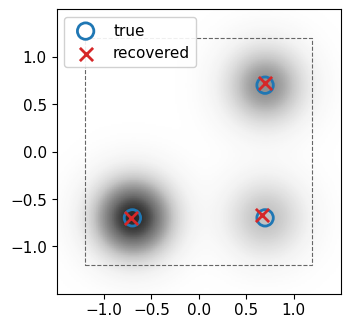

saved fig_blasso_2dgmm_b.pdf


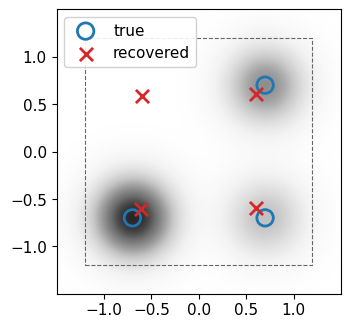

saved fig_blasso_2dgmm_c.pdf -> ../figs


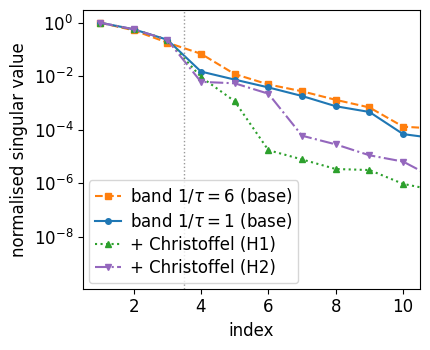

In [11]:
FIGS=os.path.abspath("../figs" if os.path.basename(os.getcwd())=="code" else "figs")
os.makedirs(FIGS,exist_ok=True)
L=BOX+0.3; gx=np.linspace(-L,L,160); XX,YY=np.meshgrid(gx,gx)
grid=np.column_stack([XX.ravel(),YY.ravel()])
dens=np.zeros(len(grid))
for a,w in zip(ATOMS,WEIGHTS):
    dens+=w*np.exp(-0.5*np.sum((grid-a)**2,axis=1)/SIGMA**2)/(2*np.pi*SIGMA**2)
dens=dens.reshape(XX.shape)

# Font sizes chosen for the printed size in the paper (panels (a),(b) at 0.305 textwidth, (c) at 0.35 textwidth,
# i.e. scaled by about 0.55 and 0.51): every tick, label and legend entry prints at about 6 pt. In (a),(b) five ticks
# per axis keep the labels apart, and the x tick labels sit a little closer to the axis so that the panel is not taller.
FS_AB=11; FS_C=12

def panel(regime,fname):
    fig,ax=plt.subplots(figsize=(3.6,3.6))
    ax.imshow(dens,extent=[-L,L,-L,L],origin="lower",cmap="Greys",alpha=.85)
    ax.scatter(ATOMS[:,0],ATOMS[:,1],s=140,facecolors="none",edgecolors="C0",lw=2,label="true")
    rec=results[regime]["atoms"]
    if rec is not None and len(rec):
        ax.scatter(rec[:,0],rec[:,1],s=90,marker="x",c="C3",lw=2,label="recovered")
    ax.add_patch(plt.Rectangle((-BOX,-BOX),2*BOX,2*BOX,fill=False,ec=".4",ls="--",lw=.8))
    ax.set_xlim(-L,L); ax.set_ylim(-L,L); ax.set_aspect("equal")
    ax.set_xticks([-1,-.5,0,.5,1]); ax.set_yticks([-1,-.5,0,.5,1]); ax.tick_params(labelsize=FS_AB); ax.tick_params(axis="x",pad=2.5)
    ax.legend(loc="upper left",fontsize=FS_AB,framealpha=.9)
    fig.tight_layout(); fig.savefig(os.path.join(FIGS,fname),bbox_inches="tight")
    print("saved",fname); plt.show()

# No titles in the PDFs: the paper labels the panels, (a) band 1/tau=1 ("smooth") and (b) band 1/tau=6 ("broad").
panel("smooth","fig_blasso_2dgmm_a.pdf")
panel("broad","fig_blasso_2dgmm_b.pdf")

fig,ax=plt.subplots(figsize=(4.4,3.6))
sb_broad=results["broad"]["svals"]; ax.semilogy(np.arange(1,len(sb_broad)+1),sb_broad/sb_broad[0],"s--",ms=4,color="C1",label="band $1/\\tau=6$ (base)")
sb=results["smooth"]["svals"];      ax.semilogy(np.arange(1,len(sb)+1),sb/sb[0],"o-",ms=4,color="C0",label="band $1/\\tau=1$ (base)")
sh1=results["smooth"]["svals_cdk"]; ax.semilogy(np.arange(1,len(sh1)+1),sh1/sh1[0],"^:",ms=5,color="C2",label="+ Christoffel (H1)")
sh2=results["smooth"]["svals_h2"];  ax.semilogy(np.arange(1,len(sh2)+1),sh2/sh2[0],"v-.",ms=5,color="C4",label="+ Christoffel (H2)")
ax.axvline(len(WEIGHTS)+.5,color=".6",ls=":",lw=1)
ax.set_xlim(0.5,10.5); ax.set_xlabel("index",fontsize=FS_C); ax.set_ylabel("normalised singular value",fontsize=FS_C)
ax.tick_params(labelsize=FS_C)
ax.legend(fontsize=FS_C,loc="lower left",handlelength=1.6,handletextpad=.5,borderpad=.35,labelspacing=.3,borderaxespad=.35)  # in the empty lower-left corner
fig.tight_layout(); fig.savefig(os.path.join(FIGS,"fig_blasso_2dgmm_c.pdf"),bbox_inches="tight")
print("saved fig_blasso_2dgmm_c.pdf ->",os.path.relpath(FIGS)); plt.show()

## 9. Figure 4: 3-D dual certificates (saved to `../figs/`)

Top row: the subgradient $\eta(x)$ for each band, with the $+1$ plane and the true atoms. Bottom row: the SoS
certificate $s_A(x)$. At band 1, $\eta$ is within $1.1\times10^{-3}$ of $+1$ at the three true atoms ($2.3\times10^{-3}$
at the recovered ones) but is degenerate along $x_1\approx0.7$: on the whole segment $x_1=0.7$ of $\mathcal X$ it stays
within $2.7\times10^{-3}$ of $1$ ($1.7\times10^{-3}$ for $|x_2|\le0.9$); Section 11 prints the values. At band 6 it is a
smooth dome that certifies the biased four-atom solution.
The PDF carries no titles: the left column is band 1, the right column band 6.

saved fig_blasso_2dgmm_certif.pdf -> ../figs


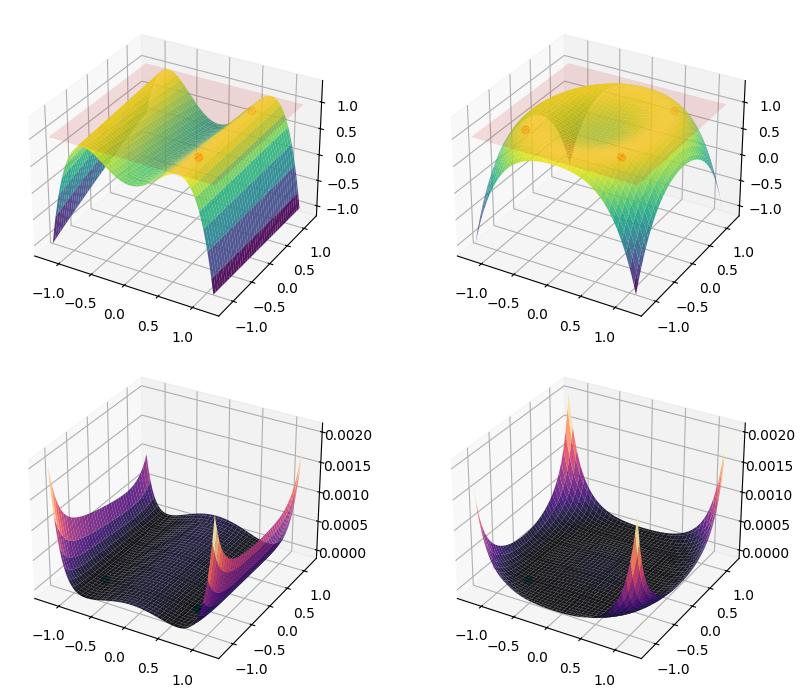

In [12]:
gc=np.linspace(-BOX,BOX,80); CX,CY=np.meshgrid(gc,gc)
cgrid=np.column_stack([CX.ravel(),CY.ravel()])
fig=plt.figure(figsize=(9.5,7.0))
for col,regime in enumerate(("smooth","broad")):
    eta=eta_surface(results[regime],cgrid).reshape(CX.shape)
    ax=fig.add_subplot(2,2,col+1,projection="3d")
    ax.plot_surface(CX,CY,eta,cmap="viridis",alpha=.9,linewidth=0,antialiased=True)
    ax.plot_surface(CX,CY,np.ones_like(CX),color="r",alpha=.12,linewidth=0)
    ax.scatter(ATOMS[:,0],ATOMS[:,1],np.ones(len(ATOMS)),c="r",s=30)
    ax.set_zlim(min(-1.2,eta.min()),max(1.4,eta.max()))
    sA=sA_surface(results[regime],cgrid)
    ax2=fig.add_subplot(2,2,col+3,projection="3d")
    if sA is not None:
        ax2.plot_surface(CX,CY,sA.reshape(CX.shape),cmap="magma",alpha=.9,linewidth=0)
        ax2.scatter(ATOMS[:,0],ATOMS[:,1],np.zeros(len(ATOMS)),c="c",s=30)
    else:
        ax2.text2D(0.2,0.5,"dual value unavailable",transform=ax2.transAxes)
fig.tight_layout(); fig.savefig(os.path.join(FIGS,"fig_blasso_2dgmm_certif.pdf"),bbox_inches="tight")
print("saved fig_blasso_2dgmm_certif.pdf ->",os.path.relpath(FIGS)); plt.show()

## 10. Recovery summary (true vs recovered)


In [13]:
def report(label, atoms, weights):
    print(f"--- {label} ---")
    if atoms is None or len(atoms)==0: print("  (no atoms)"); return
    for i in np.argsort(-np.asarray(weights)):
        a=atoms[i]; wv=float(weights[i])
        j=int(np.argmin([np.hypot(*(a-t)) for t in ATOMS]))
        print(f"  ({a[0]:+.3f},{a[1]:+.3f}) w={wv:.3f}  <- true "
              f"({ATOMS[j,0]:+.2f},{ATOMS[j,1]:+.2f}) w={WEIGHTS[j]:.2f}  | "
              f"dpos={np.hypot(*(a-ATOMS[j])):.3f}  dw={abs(wv-WEIGHTS[j]):.3f}")

print("TRUE:", [(round(float(t[0]),2),round(float(t[1]),2),round(float(w),2)) for t,w in zip(ATOMS,WEIGHTS)])
report("smooth, base", results["smooth"]["atoms"],     results["smooth"]["weights"])
report("smooth, H1",   results["smooth"]["atoms_h1"],   results["smooth"]["weights_h1"])
report("smooth, H2",   results["smooth"]["atoms_h2"],   results["smooth"]["weights_h2"])
report("broad, base",  results["broad"]["atoms"],       results["broad"]["weights"])

TRUE: [(-0.7, -0.7, 0.5), (0.7, 0.7, 0.3), (0.7, -0.7, 0.2)]
--- smooth, base ---
  (-0.716,-0.703) w=0.498  <- true (-0.70,-0.70) w=0.50  | dpos=0.016  dw=0.002
  (+0.702,+0.718) w=0.299  <- true (+0.70,+0.70) w=0.30  | dpos=0.018  dw=0.001
  (+0.667,-0.665) w=0.217  <- true (+0.70,-0.70) w=0.20  | dpos=0.048  dw=0.017
--- smooth, H1 ---
  (-0.715,-0.703) w=0.498  <- true (-0.70,-0.70) w=0.50  | dpos=0.016  dw=0.002
  (+0.702,+0.715) w=0.300  <- true (+0.70,+0.70) w=0.30  | dpos=0.016  dw=0.000
  (+0.667,-0.669) w=0.216  <- true (+0.70,-0.70) w=0.20  | dpos=0.045  dw=0.016
--- smooth, H2 ---
  (-0.716,-0.703) w=0.498  <- true (-0.70,-0.70) w=0.50  | dpos=0.016  dw=0.002
  (+0.702,+0.719) w=0.299  <- true (+0.70,+0.70) w=0.30  | dpos=0.019  dw=0.001
  (+0.664,-0.662) w=0.218  <- true (+0.70,-0.70) w=0.20  | dpos=0.052  dw=0.018
--- broad, base ---
  (-0.609,-0.603) w=0.261  <- true (-0.70,-0.70) w=0.50  | dpos=0.133  dw=0.239
  (+0.609,+0.602) w=0.211  <- true (+0.70,+0.70) w=0.30  | d

## 11. Numbers quoted in §4.4

These cells print the values that the text of §4.4 quotes, from the run above (same sample, same solves).
They do not change any result or figure above. The extra SDP solves (exact-CF moments) are logged in
Section 12.

In [14]:
# Protocol and findings: the frequency lattice, |xi^T t| at the atoms and on X, 1/Ghat on the band, and the
# CF-fit moment errors on exact data (exact CF of mu^star) and on the sample, with the noise part their difference.
def band_lattice(band, ngrid=11):                    # the frequency lattice of cf_band_moments
    g=np.linspace(-band,band,ngrid); G1,G2=np.meshgrid(g,g); XI=np.column_stack([G1.ravel(),G2.ravel()])
    return XI[np.sum(XI**2,axis=1)<=band**2+1e-9]

def cf_fit_exact(band):                              # cf_band_moments fed with the exact CF of mu^star
    XI=band_lattice(band)
    nu=(WEIGHTS[None,:]*np.exp(1j*(XI@ATOMS.T))).sum(axis=1)
    cols=[e for e in MONOS if e[0]+e[1]<=D_DATA]
    A=np.array([[(1j**(e[0]+e[1]))/(math.factorial(e[0])*math.factorial(e[1]))*xi[0]**e[0]*xi[1]**e[1]
                 for e in cols] for xi in XI])
    coef,*_=np.linalg.lstsq(np.vstack([A.real,A.imag]),np.concatenate([nu.real,nu.imag]),rcond=None)
    m=np.zeros(len(MONOS))
    for c,e in zip(coef,cols): m[IDX[e]]=c.real
    return m

mt=true_moments(); fitc=[IDX[e] for e in MONOS if e[0]+e[1]<=D_DATA]
corners=np.array([[s1*BOX,s2*BOX] for s1 in (-1,1) for s2 in (-1,1)])   # max of |xi^T x| over X is at a corner
Rt=np.linalg.norm(ATOMS,axis=1).max()
m_exact={}
for regime,band in (("smooth",BAND_SMOOTH),("broad",BAND_BROAD)):
    XI=band_lattice(band); m_exact[regime]=cf_fit_exact(band); mh=results[regime]["mhat"]
    print(f"band 1/tau={band:g} ({regime}): {len(XI)} lattice frequencies")
    print(f"  max |xi^T t| at the atoms = {np.abs(XI@ATOMS.T).max():.3f};  on X=[-{BOX},{BOX}]^2 = {np.abs(XI@corners.T).max():.3f}")
    print(f"  Xi*R = {band*Rt:.2f} with R = max||t_k|| = {Rt:.3f};  = {band*BOX*np.sqrt(2):.2f} with R = {BOX}*sqrt(2) (X in B(0,R))")
    print(f"  max 1/Ghat on the band = {np.exp(0.5*SIGMA**2*np.sum(XI**2,axis=1)).max():.3f}")
    print(f"  max moment error over |alpha|<={D_DATA}: exact CF {np.abs(m_exact[regime][fitc]-mt[fitc]).max():.4f}, "
          f"sample CF {np.abs(mh[fitc]-mt[fitc]).max():.4f}, noise part {np.abs(mh[fitc]-m_exact[regime][fitc]).max():.4f}")
    print(f"  m_0: exact CF {m_exact[regime][IDX[(0,0)]]:.4f}, sample CF {mh[IDX[(0,0)]]:.4f} (true 1)")

band 1/tau=1 (smooth): 81 lattice frequencies
  max |xi^T t| at the atoms = 0.980;  on X=[-1.2,1.2]^2 = 1.680
  Xi*R = 0.99 with R = max||t_k|| = 0.990;  = 1.70 with R = 1.2*sqrt(2) (X in B(0,R))
  max 1/Ghat on the band = 1.046
  max moment error over |alpha|<=4: exact CF 0.0105, sample CF 0.0120, noise part 0.0051
  m_0: exact CF 1.0000, sample CF 1.0000 (true 1)
band 1/tau=6 (broad): 81 lattice frequencies
  max |xi^T t| at the atoms = 5.880;  on X=[-1.2,1.2]^2 = 10.080
  Xi*R = 5.94 with R = max||t_k|| = 0.990;  = 10.18 with R = 1.2*sqrt(2) (X in B(0,R))
  max 1/Ghat on the band = 5.053
  max moment error over |alpha|<=4: exact CF 0.3979, sample CF 0.4004, noise part 0.0048
  m_0: exact CF 0.6021, sample CF 0.5996 (true 1)


In [15]:
# "Noiseless data give the same values" (band 1) and the band-6 failure "again with noiseless data":
# the same SDP and extraction on the exact-CF moments of the previous cell (no sample).
for regime in ("smooth","broad"):
    yp0,ym0,bD0,_,_,_=solve_moment_sdp(m_exact[regime],tag=f"{regime}, exact-CF data")
    M0=moment_matrix(yp0,bD0); sv0=np.linalg.svd(M0,compute_uv=False)
    print(f"[{regime}, exact-CF data] singular values of M_D(y_+)/s1: {np.round(sv0[:5]/sv0[0],4)}")
    try:
        a0,w0=extract_atoms(M0,bD0,D_ORDER,RANK_TOL); k0=w0>1e-3*np.max(np.abs(w0))
        report(f"{regime}, exact-CF data", a0[k0], w0[k0])
    except Exception as e:
        print(f"[{regime}, exact-CF data] extraction failed: {e}")

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_66280/2771737495.py:44: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.CLARABEL, time_limit=SOLVE_TLIM)


  solve [smooth, exact-CF data]: CLARABEL status=optimal_inaccurate
[smooth, exact-CF data] singular values of M_D(y_+)/s1: [1.000e+00 5.497e-01 2.201e-01 6.500e-03 5.000e-04]
--- smooth, exact-CF data ---
  (-0.713,-0.706) w=0.500  <- true (-0.70,-0.70) w=0.50  | dpos=0.014  dw=0.000
  (+0.701,+0.714) w=0.295  <- true (+0.70,+0.70) w=0.30  | dpos=0.014  dw=0.005
  (+0.663,-0.664) w=0.216  <- true (+0.70,-0.70) w=0.20  | dpos=0.052  dw=0.016


  solve [broad, exact-CF data]: CLARABEL status=optimal_inaccurate
[broad, exact-CF data] singular values of M_D(y_+)/s1: [1.     0.5136 0.1782 0.0669 0.0101]
--- broad, exact-CF data ---
  (-0.605,-0.605) w=0.266  <- true (-0.70,-0.70) w=0.50  | dpos=0.134  dw=0.234
  (+0.604,+0.604) w=0.209  <- true (+0.70,+0.70) w=0.30  | dpos=0.135  dw=0.091
  (+0.600,-0.601) w=0.103  <- true (+0.70,-0.70) w=0.20  | dpos=0.141  dw=0.097
  (-0.594,+0.590) w=0.046  <- true (-0.70,-0.70) w=0.50  | dpos=1.295  dw=0.454


In [16]:
# Band 1: errors of base / H1 / H2 (text: positions to 0.05, weights to 0.02; the atoms-move and "slightly better/worse" claims were
# dropped by #60; the paper now quotes the 20-sample distribution, code/robustness.ipynb); band 6: pull towards the origin and the spurious atom;
# singular values behind panel (c); share of the mass carried by y_-.
def nearest(atoms, t): return int(np.argmin([np.hypot(*(a-t)) for a in atoms]))
R=results["smooth"]; base_idx=[nearest(R["atoms"],t) for t in ATOMS]
for lab,(A,W) in {"base":(R["atoms"],R["weights"]),"H1":(R["atoms_h1"],R["weights_h1"]),
                  "H2":(R["atoms_h2"],R["weights_h2"])}.items():
    idx=[nearest(A,t) for t in ATOMS]
    dp=[np.hypot(*(A[j]-t)) for j,t in zip(idx,ATOMS)]; dw=[abs(W[j]-w) for j,w in zip(idx,WEIGHTS)]
    line=f"band 1, {lab}: {len(A)} atoms, dpos={np.round(dp,4)}, dw={np.round(dw,4)}, max dpos={max(dp):.4f}, max dw={max(dw):.4f}"
    if lab!="base":
        mv=[np.hypot(*(A[j]-R["atoms"][b])) for j,b in zip(idx,base_idx)]
        line+=f" | moves vs base {np.round(mv,4)} (max {max(mv):.4f})"
    print(line)
print(f"H1: {R['n_h1']} of N_CDK={N_CDK} re-solves accepted")
B=results["broad"]; bidx=[nearest(B["atoms"],t) for t in ATOMS]
print("band 6: distance true -> nearest recovered:", np.round([np.hypot(*(B["atoms"][j]-t)) for j,t in zip(bidx,ATOMS)],3),
      "| norms true -> recovered:", [f"{np.linalg.norm(t):.3f}->{np.linalg.norm(B['atoms'][j]):.3f}" for j,t in zip(bidx,ATOMS)])
spur=[k for k in range(len(B["atoms"])) if k not in bidx]
print("band 6: unmatched (spurious) atoms:", [(tuple(np.round(B["atoms"][k],3)), round(float(B["weights"][k]),3)) for k in spur])
for lab,sv in (("band 1 base",R["svals"]),("band 1 H1",R["svals_cdk"]),("band 1 H2",R["svals_h2"]),("band 6 base",B["svals"])):
    print(f"{lab:12s} singular values of M_D(y_+)/s1: {np.round(sv[:5]/sv[0],4)}  (s3/s4 = {sv[2]/sv[3]:.1f}, s4/s5 = {sv[3]/sv[4]:.1f})")
for regime in ("smooth","broad"):
    r=results[regime]; y0p,y0m=r["yp"][IDX[(0,0)]],r["ym"][IDX[(0,0)]]
    print(f"[{regime}] y_+,0 = {y0p:.4f}, y_-,0 = {y0m:.4f}, y_-,0/(y_+,0+y_-,0) = {y0m/(y0p+y0m):.4f}")

band 1, base: 3 atoms, dpos=[0.0157 0.0181 0.0479], dw=[0.0019 0.0007 0.0172], max dpos=0.0479, max dw=0.0172
band 1, H1: 3 atoms, dpos=[0.0157 0.0155 0.0452], dw=[0.0019 0.0005 0.016 ], max dpos=0.0452, max dw=0.0160 | moves vs base [0.     0.0026 0.0039] (max 0.0039)
band 1, H2: 3 atoms, dpos=[0.0163 0.0189 0.0521], dw=[0.0021 0.0011 0.0178], max dpos=0.0521, max dw=0.0178 | moves vs base [0.0007 0.0008 0.0043] (max 0.0043)
H1: 4 of N_CDK=4 re-solves accepted
band 6: distance true -> nearest recovered: [0.133 0.134 0.14 ] | norms true -> recovered: ['0.990->0.857', '0.990->0.856', '0.990->0.850']
band 6: unmatched (spurious) atoms: [((np.float64(-0.599), np.float64(0.587)), 0.047)]
band 1 base  singular values of M_D(y_+)/s1: [1.     0.566  0.2308 0.0149 0.0075]  (s3/s4 = 15.5, s4/s5 = 2.0)
band 1 H1    singular values of M_D(y_+)/s1: [1.     0.5636 0.2308 0.0093 0.0012]  (s3/s4 = 24.7, s4/s5 = 8.1)
band 1 H2    singular values of M_D(y_+)/s1: [1.     0.568  0.2296 0.0061 0.0054]  (s

In [17]:
# Certificate eta at band 1 (text: "within 2.3e-3 of 1 at the three atoms", "within 2.7e-3 of 1 along the whole line x_1=0.7").
gE=np.linspace(-BOX,BOX,161); G1,G2=np.meshgrid(gE,gE); PE=np.column_stack([G1.ravel(),G2.ravel()])
for regime in ("smooth","broad"):
    E=eta_surface(results[regime],PE)
    print(f"[{regime}] on the 161^2 grid of X: max eta = {E.max():.5f}, min eta = {E.min():.4f}")
et,er=eta_surface(R,ATOMS),eta_surface(R,R["atoms"])
print(f"band 1: eta at the true atoms      = {np.round(et,5)}, max |eta-1| = {np.abs(et-1).max():.2e}")
print(f"band 1: eta at the recovered atoms = {np.round(er,5)}, max |eta-1| = {np.abs(er-1).max():.2e}")
x2=np.linspace(-BOX,BOX,2401)
def eta_line(x1): return eta_surface(R,np.column_stack([np.full_like(x2,x1),x2]))
e07=eta_line(0.7); inner=np.abs(x2)<=0.9+1e-12
print(f"band 1, segment x_1=0.7, x_2 in [-{BOX},{BOX}]: eta in [{e07.min():.5f}, {e07.max():.5f}], 1-min = {1-e07.min():.2e}"
      f" (min at x_2={x2[np.argmin(e07)]:+.3f})")
print(f"band 1, segment x_1=0.7, |x_2|<=0.9     : eta in [{e07[inner].min():.5f}, {e07[inner].max():.5f}], 1-min = {1-e07[inner].min():.2e}")
x1s=np.linspace(0.6,0.8,201); mins=np.array([eta_line(v).min() for v in x1s]); b=int(np.argmax(mins))
print(f"band 1, best vertical segment x_1={x1s[b]:.3f}: min eta = {mins[b]:.5f}, 1-min = {1-mins[b]:.2e}")
# SoS certificate s_A = v_D^T A v_D, A the dual of M_D(y_+) >= 0 (text: at band 1 "s_A >= 0 vanishes there" at the three atoms and
# "s_A below 1e-6 along the whole line x_1=0.7"): at the atoms, on the same segment, and on the grids of Figure 4 (80^2) and above (161^2).
# By stationarity beta*(1-eta) = s_A + sum_i g_i s_B_i >= s_A on X (up to the solver residual), printed for comparison.
fmt=lambda v: "["+", ".join(f"{t:.2e}" for t in np.atleast_1d(v))+"]"
sA_t,sA_r=sA_surface(R,ATOMS),sA_surface(R,R["atoms"]); sA07=sA_surface(R,np.column_stack([np.full_like(x2,0.7),x2]))
print(f"band 1: s_A at the true atoms      = {fmt(sA_t)}")
print(f"band 1: s_A at the recovered atoms = {fmt(sA_r)}")
print(f"band 1, segment x_1=0.7, x_2 in [-{BOX},{BOX}]: s_A in [{sA07.min():.2e}, {sA07.max():.2e}] (max at x_2={x2[np.argmax(sA07)]:+.3f});"
      f" beta*(1-min eta) = {BETA*(1-e07.min()):.2e}")
print(f"band 1, segment x_1=0.7, |x_2|<=0.9     : s_A in [{sA07[inner].min():.2e}, {sA07[inner].max():.2e}]")
for regime in ("smooth","broad"):
    S80,S161=sA_surface(results[regime],cgrid),sA_surface(results[regime],PE)
    print(f"[{regime}] s_A on the 80^2 grid of Figure 4: min = {S80.min():.2e}, max = {S80.max():.2e};"
          f" on the 161^2 grid: min = {S161.min():.2e}, max = {S161.max():.2e}")
print(f"band 6: s_A at the true atoms = {fmt(sA_surface(B,ATOMS))}, at the recovered atoms = {fmt(sA_surface(B,B['atoms']))}")

[smooth] on the 161^2 grid of X: max eta = 1.00000, min eta = -1.0000
[broad] on the 161^2 grid of X: max eta = 1.00000, min eta = -1.0000
band 1: eta at the true atoms      = [0.99891 0.99891 0.9996 ], max |eta-1| = 1.09e-03
band 1: eta at the recovered atoms = [0.99913 1.      0.99771], max |eta-1| = 2.29e-03
band 1, segment x_1=0.7, x_2 in [-1.2,1.2]: eta in [0.99728, 0.99999], 1-min = 2.72e-03 (min at x_2=+1.200)
band 1, segment x_1=0.7, |x_2|<=0.9     : eta in [0.99835, 0.99999], 1-min = 1.65e-03


band 1, best vertical segment x_1=0.703: min eta = 0.99792, 1-min = 2.08e-03
band 1: s_A at the true atoms      = [2.48e-07, 2.46e-07, 9.04e-08]
band 1: s_A at the recovered atoms = [1.97e-07, 4.73e-10, 5.16e-07]
band 1, segment x_1=0.7, x_2 in [-1.2,1.2]: s_A in [2.72e-09, 9.81e-07] (max at x_2=+1.200); beta*(1-min eta) = 2.72e-06
band 1, segment x_1=0.7, |x_2|<=0.9     : s_A in [2.72e-09, 3.80e-07]


[smooth] s_A on the 80^2 grid of Figure 4: min = 2.45e-10, max = 2.00e-03; on the 161^2 grid: min = 6.73e-11, max = 2.00e-03
[broad] s_A on the 80^2 grid of Figure 4: min = 4.73e-10, max = 2.00e-03; on the 161^2 grid: min = 5.85e-11, max = 2.00e-03
band 6: s_A at the true atoms = [7.38e-06, 7.24e-06, 7.15e-06], at the recovered atoms = [5.48e-09, 8.45e-09, 3.54e-08, 1.78e-07]


## 12. Solver statuses

Every cvxpy solve of this notebook, in order: tag, solver, status (and the Clarabel error when SCS was used).

In [18]:
from collections import Counter
for tag,solver,status,note in SOLVE_LOG:
    print(f"  {tag:28s} {solver:9s} {status}" + (f"  ({note})" if note else ""))
print("counts:", dict(Counter((solver,status) for _,solver,status,_ in SOLVE_LOG)))

  smooth, base                 CLARABEL  optimal_inaccurate
  smooth, H1 re-solve 1        CLARABEL  optimal_inaccurate
  smooth, H1 re-solve 2        CLARABEL  optimal_inaccurate
  smooth, H1 re-solve 3        CLARABEL  optimal_inaccurate
  smooth, H1 re-solve 4        CLARABEL  optimal_inaccurate
  smooth, H2                   CLARABEL  optimal_inaccurate
  broad, base                  CLARABEL  optimal_inaccurate
  smooth, exact-CF data        CLARABEL  optimal_inaccurate
  broad, exact-CF data         CLARABEL  optimal_inaccurate
counts: {('CLARABEL', 'optimal_inaccurate'): 9}
